# Time-Frequency Analysis

## Goal
Understand how brain rhythms change while listening to music.

## Frequency Bands
- **Delta**: 1-4 Hz
- **Theta**: 4-8 Hz  
- **Alpha**: 8-13 Hz
- **Beta**: 13-30 Hz
- **Gamma**: 30-50 Hz

## Research Questions
1. Do alpha rhythms increase when people enjoy music?
2. Does beta activity increase during rhythmic sections?

In [ ]:
# Import MNE for EEG analysis
import mne
from mne.time_frequency import tfr_morlet, tfr_multitaper
from mne.preprocessing import ICA
# Import EvokedArray for topomap plotting
try:
    from mne import EvokedArray
except ImportError:
    from mne.evoked import EvokedArray
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Define base path to the dataset
base_path = Path(r'C:\Users\jessi\lab-Hu\cogs189')
import pandas as pd
import numpy as np

# Set MNE logging to reduce verbosity
mne.set_log_level('WARNING')

print("MNE imported successfully!")
print(f"MNE version: {mne.__version__}")

MNE imported successfully!
MNE version: 1.11.0


In [ ]:
# Function to load EEG data for a specific subject and song
def load_eeg_data(subject_id, song_id, base_path):
    """
    Load EEG data for a specific subject and song (session).
    
    Parameters:
    -----------
    subject_id : int
        Subject number (1-20)
    song_id : int
        Song number (1-12), corresponds to run number
    base_path : Path
        Base path to the dataset
        
    Returns:
    --------
    raw : mne.io.Raw
        Raw EEG data
    events : array
        Event markers
    event_id : dict
        Event ID mapping
    """
    subject_id = int(subject_id)
    song_id = int(song_id)
    sub_str = f"sub-{subject_id:03d}"
    ses_str = f"ses-{song_id:02d}"
    run_str = f"run-{song_id}"
    eeg_file = base_path / sub_str / ses_str / 'eeg' / f"{sub_str}_{ses_str}_task-MusicListening_{run_str}_eeg.set"
    events_file = base_path / sub_str / ses_str / 'eeg' / f"{sub_str}_{ses_str}_task-MusicListening_{run_str}_events.tsv"
    
    if not eeg_file.exists():
        print(f"File not found: {eeg_file}")
        return None, None, None
    
    try:
        raw = mne.io.read_raw_eeglab(eeg_file, preload=True, verbose=False)
        
        events_df = pd.read_csv(events_file, sep='\t')
        
        duration = raw.times[-1]
        sfreq = raw.info['sfreq']
        
        # Filter events that are within data range
        if 'onset' in events_df.columns:
            events_in_range = events_df[
                (events_df['onset'] >= 0) & 
                (events_df['onset'] < duration)
            ].copy()
        else:
            # If no onset column, use sample column
            events_in_range = events_df[
                (events_df['sample'] / sfreq >= 0) & 
                (events_df['sample'] / sfreq < duration)
            ].copy()
        
        if len(events_in_range) == 0:
            print(f"  Warning: No events found within data range (0-{duration:.2f}s)")
            return raw, np.array([]), {}
        
        # Try multiple event types in order of preference
        # 1. stim (baseline/music start - often marks the music listening period)
        # 2. clyp (close eyes beep - music starts after this)
        # 3. stm+ (music stimulus start - preferred but may be outside range)
        # 4. fxcl (silence before music)
        event_types = ['stim', 'clyp', 'stm+', 'fxcl']
        music_events = None
        selected_event_type = None
        
        for event_type in event_types:
            candidate_events = events_in_range[events_in_range['value'] == event_type].copy()
            if len(candidate_events) > 0:
                music_events = candidate_events
                selected_event_type = event_type
                break
    
        if music_events is None or len(music_events) == 0:
            print("  Warning: No preferred event types found, using first event in data range")
            music_events = events_in_range.iloc[[0]]
            selected_event_type = music_events.iloc[0]['value']
        
        first_event = music_events.iloc[0]
        
        if 'onset' in first_event:
            event_time = first_event['onset']
            onset_sample = int(event_time * sfreq)
        else:
            onset_sample = int(first_event['sample'])
            event_time = onset_sample / sfreq
        
        if onset_sample >= len(raw.times):
            print(f"  Warning: Event sample {onset_sample} exceeds data length {len(raw.times)}")
            return raw, np.array([]), {}
        
        events_array = np.array([[onset_sample, 0, 1]])
        event_id = {'music_start': 1}
        
        print(f"  Using {selected_event_type} event at {event_time:.2f}s (sample {onset_sample})")
        print(f"  Recording duration: {duration:.2f}s, available time after event: {duration - event_time:.2f}s")
        
        return raw, events_array, event_id
        
    except Exception as e:
        print(f"Error loading {eeg_file}: {e}")
        return None, None, None

print("Testing EEG data loading...")
test_raw, test_events, test_event_id = load_eeg_data(1, 1, base_path)
if test_raw is not None:
    print(f"✓ Successfully loaded EEG data")
    print(f"  Channels: {len(test_raw.ch_names)}")
    print(f"  Sampling rate: {test_raw.info['sfreq']} Hz")
    print(f"  Duration: {test_raw.times[-1]:.2f} seconds")
    print(f"  Events found: {len(test_events)}")
else:
    print("✗ Failed to load EEG data")

Testing EEG data loading...
  Using stim event at 7.41s (sample 1852)
  Recording duration: 136.03s, available time after event: 128.62s
✓ Successfully loaded EEG data
  Channels: 129
  Sampling rate: 250.0 Hz
  Duration: 136.03 seconds
  Events found: 1


In [ ]:
# Preprocessing function
def preprocess_eeg(raw, apply_filter=True, l_freq=1.0, h_freq=50.0):
    """
    Preprocess EEG data: filter and set montage if needed.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    apply_filter : bool
        Whether to apply bandpass filter
    l_freq : float
        Low frequency cutoff
    h_freq : float
        High frequency cutoff
        
    Returns:
    --------
    raw : mne.io.Raw
        Preprocessed raw data
    """
    # Make a copy to avoid modifying original
    raw = raw.copy()
    
    if apply_filter:
        raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin', verbose=False)
    
    raw.set_eeg_reference('average', projection=False, verbose=False)
    
    return raw

if test_raw is not None:
    print("Preprocessing test data...")
    test_raw_processed = preprocess_eeg(test_raw, apply_filter=True)
    print(f"✓ Preprocessing complete")
    print(f"  Filter applied: 1-50 Hz")
    print(f"  Reference: Average")

Preprocessing test data...
✓ Preprocessing complete
  Filter applied: 1-50 Hz
  Reference: Average


In [ ]:
# Create epochs around music listening
def create_music_epochs(raw, events, event_id, tmin=-1.0, tmax=120.0):
    """
    Create epochs around music listening periods.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Preprocessed raw data
    events : array
        Event markers
    event_id : dict
        Event ID mapping
    tmin : float
        Start time relative to event (seconds)
    tmax : float
        End time relative to event (seconds)
        
    Returns:
    --------
    epochs : mne.Epochs
        Epochs object
    """
    duration = raw.times[-1]
    sfreq = raw.info['sfreq']
    
    if events is None or len(events) == 0:
        print("  No events found, creating fixed-length epochs...")
        events = mne.make_fixed_length_events(raw, id=1, duration=2.0, start=1.0, stop=duration-1.0)
        event_id = {'music': 1}
    else:
        event_times = events[:, 0] / sfreq
        
        valid_events = []
        for i, event_time in enumerate(event_times):
            if event_time + tmin >= 0 and event_time + tmax <= duration:
                valid_events.append(i)
        
        if len(valid_events) == 0:
            print(f"  Events outside valid range, creating fixed-length epochs...")
            events = mne.make_fixed_length_events(raw, id=1, duration=2.0, start=1.0, stop=duration-1.0)
            event_id = {'music': 1}
        else:
            events = events[valid_events]
            print(f"  Using {len(events)} valid event(s) out of {len(event_times)} total")
            if event_times[valid_events[0]] + tmax > duration:
                tmax = duration - event_times[valid_events[0]] - 0.1
                print(f"  Adjusted tmax to {tmax:.1f}s to fit within recording")
    
    try:
        epochs = mne.Epochs(raw, events, event_id=event_id, 
                          tmin=tmin, tmax=tmax,
                          baseline=(tmin, 0) if tmin < 0 else None, 
                          preload=True,
                          verbose=False)
        return epochs
    except Exception as e:
        print(f"  Error creating epochs: {e}")
        print("  Falling back to fixed-length epochs...")
        events = mne.make_fixed_length_events(raw, id=1, duration=2.0, start=1.0, stop=duration-1.0)
        event_id = {'music': 1}
        epochs = mne.Epochs(raw, events, event_id=event_id, 
                           tmin=0, tmax=2.0,
                           baseline=None, 
                           preload=True,
                           verbose=False)
        return epochs

if test_raw_processed is not None:
    print("Creating epochs...")
    test_epochs = create_music_epochs(test_raw_processed, test_events, test_event_id, 
                                      tmin=-1.0, tmax=min(120.0, test_raw_processed.times[-1]))
    print(f"✓ Epochs created")
    print(f"  Number of epochs: {len(test_epochs)}")
    print(f"  Time range: {test_epochs.tmin:.1f} to {test_epochs.tmax:.1f} seconds")

Creating epochs...
  No events found, creating fixed-length epochs...
✓ Epochs created
  Number of epochs: 8
  Time range: -1.0 to 120.0 seconds


In [65]:
# Preprocess EEG data and create epochs
def preprocess_and_epoch(raw, events, event_id, tmin=-1, tmax=120):
    """
    Preprocess raw EEG and create epochs around music listening
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    events : array
        Events array
    event_id : dict
        Event ID mapping
    tmin : float
        Start time before event (seconds)
    tmax : float
        End time after event (seconds)
    
    Returns:
    --------
    epochs : mne.Epochs
        Epoched data
    """
    if raw is None or events is None:
        return None
    
    data_duration = raw.times[-1]
    if tmax > data_duration:
        print(f"Warning: tmax ({tmax}s) exceeds data duration ({data_duration:.2f}s). Adjusting to {data_duration:.2f}s")
        tmax = data_duration - 0.1  # Leave small buffer
    
    sfreq = raw.info['sfreq']
    valid_events = []
    for event in events:
        event_time = event[0] / sfreq
        
        available_time_after = data_duration - event_time
        
        adjusted_tmax = min(tmax, available_time_after - 0.1)  
        
        if event_time + adjusted_tmax <= data_duration and event_time + tmin >= 0:
            valid_events.append(event)
            if adjusted_tmax < tmax:
                print(f"Adjusted tmax from {tmax}s to {adjusted_tmax:.2f}s to fit data")
                tmax = adjusted_tmax
        else:
            print(f"Warning: Event at {event_time:.2f}s cannot fit epoch window")
            print(f"  Available time after event: {available_time_after:.2f}s")
            print(f"  Required: {tmax - tmin:.2f}s")
    
    if len(valid_events) == 0:
        print("Warning: No valid events found within data range")
        print(f"  Data duration: {data_duration:.2f}s")
        if len(events) > 0:
            event_times = [e[0] / sfreq for e in events]
            print(f"  Event times: {event_times}")
        return None
    
    events = np.array(valid_events)
    
    # Set montage if available (for 128 channel EGI system)
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, match_case=False, on_missing='ignore', verbose=False)
    except:
        pass
    
    raw_filtered = raw.copy().filter(l_freq=1, h_freq=50, verbose=False)
    
    try:
        epochs = mne.Epochs(raw_filtered, events, event_id, 
                           tmin=tmin, tmax=tmax, 
                           baseline=(tmin, 0),
                           preload=True, verbose=False,
                           reject_by_annotation=False)
        
        if len(epochs) == 0:
            print("Warning: No valid epochs created")
            return None
        
        if epochs.get_data().size == 0:
            print("Warning: Epoch data is empty")
            return None
            
        return epochs
    except Exception as e:
        print(f"Error creating epochs: {e}")
        return None

# Test the preprocessing and epoching functions
# First, load test data if not already loaded
if 'raw' not in globals() or globals().get('raw') is None:
    test_subject = 1
    test_song = 1
    raw, events, event_id = load_eeg_data(test_subject, test_song, base_path)

if raw is not None and events is not None:
    data_duration = raw.times[-1]
    epoch_tmax = min(120, data_duration - 5)  # Leave 5s buffer
    
    print(f"Data duration: {data_duration:.2f}s, using epoch window: -1 to {epoch_tmax:.2f}s")
    epochs = preprocess_and_epoch(raw, events, event_id, tmin=-1, tmax=epoch_tmax)
    if epochs is not None:
        print(f"✓ Created epochs")
        print(f"  Number of epochs: {len(epochs)}")
        print(f"  Epoch duration: {epochs.tmax - epochs.tmin:.2f} seconds")
        print(f"  Number of channels: {len(epochs.ch_names)}")
        print(f"  Epoch data shape: {epochs.get_data().shape}")
    else:
        print("✗ Failed to create epochs")
        print("  Debugging info:")
        if raw is not None:
            print(f"    Raw data duration: {raw.times[-1]:.2f}s")
        if events is not None:
            print(f"    Number of events: {len(events)}")
            if len(events) > 0:
                sfreq = raw.info['sfreq'] if raw is not None else 250
                event_times = events[:, 0] / sfreq
                print(f"    Event times: {event_times}")
else:
    print("Skipping preprocessing test - no data loaded")

  Using stim event at 7.41s (sample 1852)
  Recording duration: 136.03s, available time after event: 128.62s
Data duration: 136.03s, using epoch window: -1 to 120.00s
✓ Created epochs
  Number of epochs: 1
  Epoch duration: 121.00 seconds
  Number of channels: 129
  Epoch data shape: (1, 129, 30251)


In [ ]:
# Time-Frequency Analysis using Morlet Wavelets
def compute_time_frequency(epochs, freqs=np.arange(1, 51, 1), n_cycles=5):
    """
    Compute time-frequency representation using Morlet wavelets
    
    Parameters:
    -----------
    epochs : mne.Epochs
        Epoched EEG data
    freqs : array
        Frequencies to analyze
    n_cycles : float or array
        Number of cycles for Morlet wavelet
    
    Returns:
    --------
    power : mne.time_frequency.EpochsTFR
        Time-frequency power
    """
    if epochs is None:
        print("Error: epochs is None")
        return None
    
    # Validate epochs
    if len(epochs) == 0:
        print("Error: epochs is empty")
        return None
    
    # Check epoch data
    epoch_data = epochs.get_data()
    if epoch_data.size == 0:
        print("Error: epoch data is empty")
        return None
    
    print(f"Computing TFR for {len(epochs)} epochs, shape: {epoch_data.shape}")
    
    try:
        if isinstance(n_cycles, (int, float)):
            n_cycles_array = freqs / 2.0
            n_cycles_array = np.clip(n_cycles_array, 2, 10)  # Limit between 2 and 10 cycles
        else:
            n_cycles_array = n_cycles
        
        print(f"Using n_cycles: min={np.min(n_cycles_array):.1f}, max={np.max(n_cycles_array):.1f}")
        
        power = tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles_array, 
                          return_itc=False, average=False, verbose=False)
        return power
    except Exception as e:
        print(f"Error computing time-frequency: {e}")
        import traceback
        traceback.print_exc()
        return None

if 'epochs' in locals() and epochs is not None:
    print("Computing time-frequency representation...")
    print(f"Epochs info: {len(epochs)} epochs, duration: {epochs.tmax - epochs.tmin:.2f}s")
    
    freqs = np.arange(1, 51, 2)  # 1-50 Hz in 2 Hz steps (faster for testing)
    print(f"Using frequencies: {freqs.min():.1f}-{freqs.max():.1f} Hz, step: {freqs[1]-freqs[0]:.1f} Hz")
    
    power = compute_time_frequency(epochs, freqs=freqs, n_cycles=5)
    
    if power is not None:
        print(f"✓ Time-frequency analysis complete")
        print(f"  Frequency range: {power.freqs.min():.1f}-{power.freqs.max():.1f} Hz")
        print(f"  Time range: {power.times.min():.2f}-{power.times.max():.2f} seconds")
        print(f"  Shape: {power.data.shape}")
        print(f"  Number of epochs: {len(power)}")
    else:
        print("✗ Failed to compute time-frequency")
        print("  Check that epochs contain valid data")
else:
    print("Skipping time-frequency test - no epochs available")
    if 'raw' in locals() and raw is not None and 'events' in locals() and events is not None:
        print("  Attempting to recreate epochs...")
        epochs = preprocess_and_epoch(raw, events, event_id, tmin=-1, tmax=120)
        if epochs is not None and len(epochs) > 0:
            print(f"  ✓ Recreated epochs: {len(epochs)} epochs")
            freqs = np.arange(1, 51, 2)
            power = compute_time_frequency(epochs, freqs=freqs, n_cycles=5)

Computing time-frequency representation...
Epochs info: 1 epochs, duration: 121.00s
Using frequencies: 1.0-49.0 Hz, step: 2.0 Hz
Computing TFR for 1 epochs, shape: (1, 129, 30251)
Using n_cycles: min=2.0, max=10.0
✓ Time-frequency analysis complete
  Frequency range: 1.0-49.0 Hz
  Time range: -1.00-120.00 seconds
  Shape: (1, 129, 25, 30251)
  Number of epochs: 1


In [ ]:
# Time-Frequency Analysis using Morlet Wavelets
def compute_tfr(epochs, freqs=np.arange(1, 51, 1), n_cycles=5, return_itc=False):
    """
    Compute time-frequency representation using Morlet wavelets.
    
    Parameters:
    -----------
    epochs : mne.Epochs
        Epochs object
    freqs : array
        Frequencies to analyze (Hz)
    n_cycles : float or array
        Number of cycles for Morlet wavelet
    return_itc : bool
        Whether to return inter-trial coherence
        
    Returns:
    --------
    power : mne.time_frequency.TFR
        Time-frequency power
    """
    power = tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, 
                      return_itc=return_itc, average=True, 
                      decim=2, verbose=False)
    return power

if test_epochs is not None and len(test_epochs) > 0:
    print("Computing time-frequency representation...")
    print("  This may take a moment...")
    
    test_freqs = np.arange(1, 51, 2)  # Every 2 Hz for faster computation
    test_power = compute_tfr(test_epochs, freqs=test_freqs, n_cycles=5)
    
    print(f"✓ TFR computed")
    print(f"  Frequency range: {test_power.freqs.min():.1f} - {test_power.freqs.max():.1f} Hz")
    print(f"  Time range: {test_power.times.min():.1f} - {test_power.times.max():.1f} seconds")
    print(f"  Shape: {test_power.data.shape}")

Computing time-frequency representation...
  This may take a moment...


✓ TFR computed
  Frequency range: 1.0 - 49.0 Hz
  Time range: -1.0 - 120.0 seconds
  Shape: (129, 25, 15126)


In [13]:
import matplotlib.pyplot as plt

In [ ]:

FREQ_BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 50)
}

def extract_band_power(tfr, band_name, channels=None):
    """
    Extract average power for a specific frequency band.
    
    Parameters:
    -----------
    tfr : mne.time_frequency.TFR
        Time-frequency representation
    band_name : str
        Name of frequency band ('delta', 'theta', 'alpha', 'beta', 'gamma')
    channels : list or None
        Channel names to include. If None, uses all channels.
        
    Returns:
    --------
    band_power : array
        Average power in the band (channels x times)
    """
    if band_name not in FREQ_BANDS:
        raise ValueError(f"Unknown band: {band_name}. Choose from {list(FREQ_BANDS.keys())}")
    
    fmin, fmax = FREQ_BANDS[band_name]
    
    freq_mask = (tfr.freqs >= fmin) & (tfr.freqs <= fmax)
    
    if channels is None:
        data = tfr.data[:, freq_mask, :]  # channels x freqs x times
    else:
        ch_indices = [tfr.ch_names.index(ch) for ch in channels if ch in tfr.ch_names]
        data = tfr.data[ch_indices, :, :][:, freq_mask, :]
    band_power = np.mean(data, axis=1)  # channels x times
    
    return band_power

print("Frequency bands and extract_band_power function defined!")

Frequency bands and extract_band_power function defined!


Plotting spectrogram for channel: E65


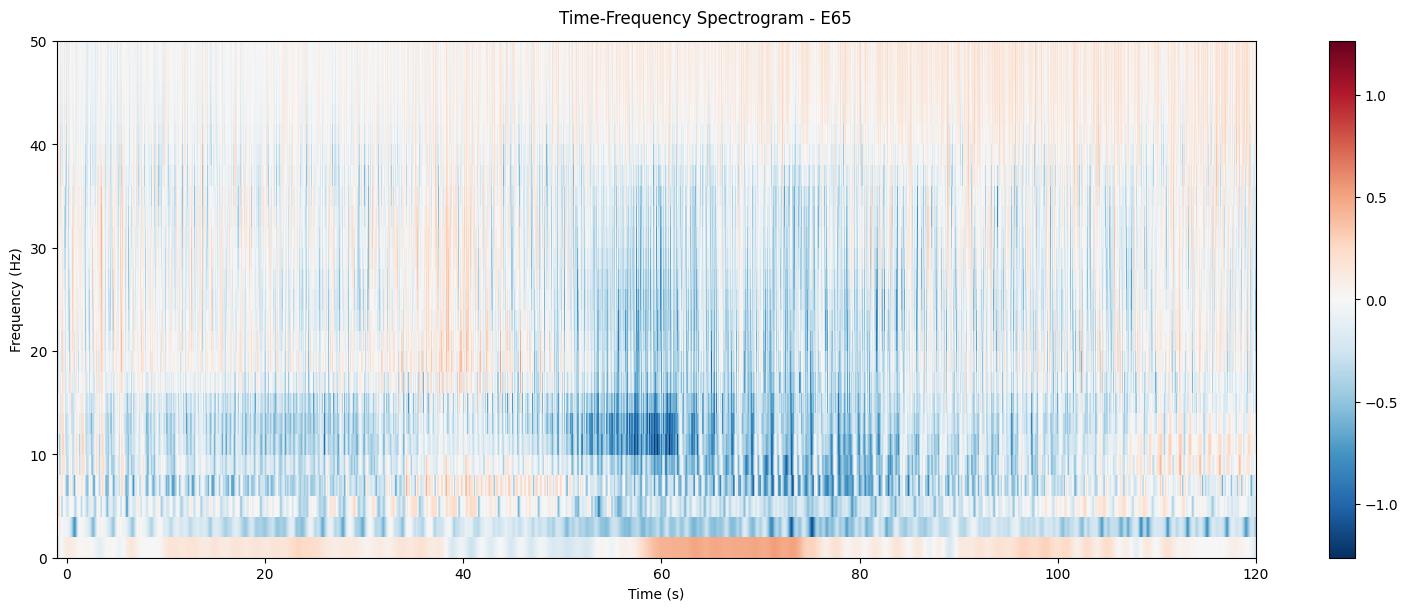

✓ Spectrogram plotted


In [ ]:
# Graph 1: Time-Frequency Spectrogram
if 'test_power' in locals() and test_power is not None:
    central_ch_idx = len(test_power.ch_names) // 2
    central_ch = test_power.ch_names[central_ch_idx]
    
    print(f"Plotting spectrogram for channel: {central_ch}")
    
    fig_result = test_power.plot([central_ch_idx], 
                            baseline=(None, 0), 
                            mode='logratio',
                            title=f'Time-Frequency Spectrogram - {central_ch}',
                            show=False)
    fig = fig_result[0] if isinstance(fig_result, list) else fig_result
    fig.set_size_inches(14, 6)
    # plt.tight_layout()
    plt.show()
        
    print("✓ Spectrogram plotted")

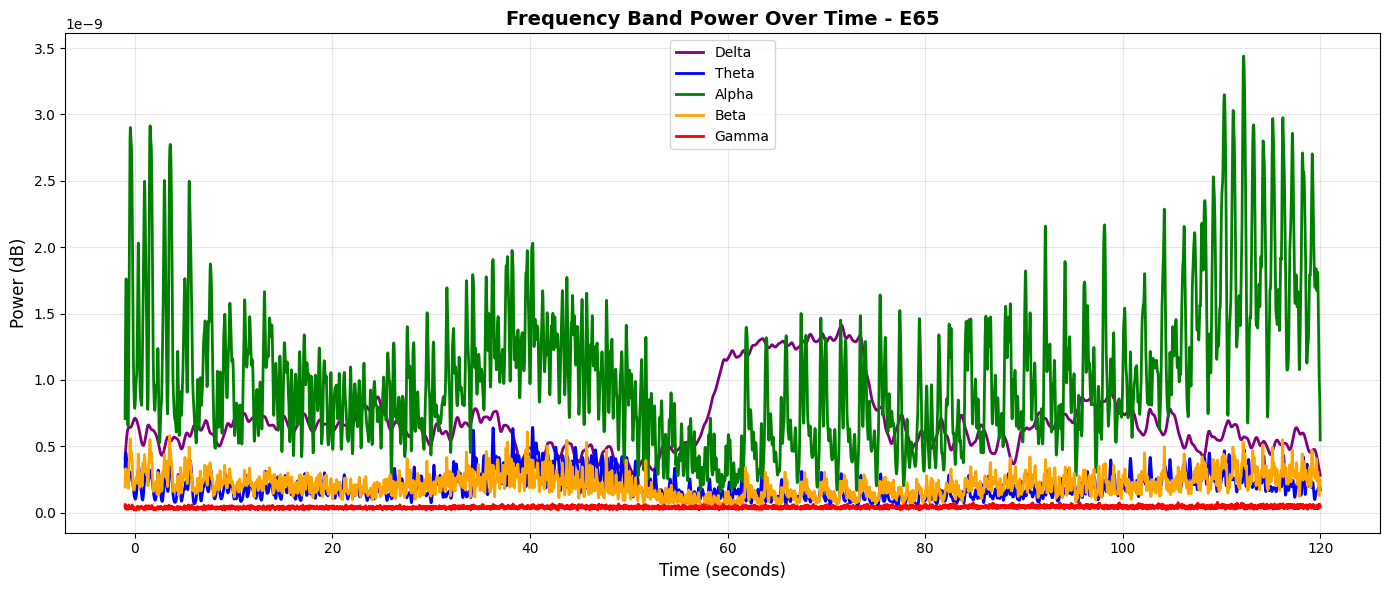

✓ Frequency band power plotted


In [ ]:
# Graph 2: Power in Different Frequency Bands Over Time
if 'test_power' in locals() and test_power is not None:
    band_powers = {}
    for band_name in FREQ_BANDS.keys():
        band_powers[band_name] = extract_band_power(test_power, band_name)
    
    central_ch_idx = len(test_power.ch_names) // 2
    central_ch = test_power.ch_names[central_ch_idx]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors = {'delta': 'purple', 'theta': 'blue', 'alpha': 'green', 
              'beta': 'orange', 'gamma': 'red'}
    
    for band_name, power in band_powers.items():
        power_trace = power[central_ch_idx, :]
        ax.plot(test_power.times, power_trace, 
               label=band_name.capitalize(), 
               color=colors[band_name], 
               linewidth=2)
    
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Power (dB)', fontsize=12)
    ax.set_title(f'Frequency Band Power Over Time - {central_ch}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("✓ Frequency band power plotted")

In [ ]:
behav_data_path = base_path / 'stimuli' / 'Behavioural_data'

df = pd.read_csv(behav_data_path, sep='\t', skipinitialspace=True)

df.columns = df.columns.str.strip()
columns = ['Subject', 'Song_ID', 'Enjoyment', 'Familiarity']
df = df[['Unnamed: 1', 'Unnamed: 3','Familiarity']].reset_index()
df.columns =columns
df.head()

,Subject,Song_ID,Enjoyment,Familiarity
0,1,1,2,2
1,1,2,3,2
2,1,3,3,3
3,1,4,2,2
4,1,5,2,2


In [40]:
# Research Question 1: Do alpha rhythms increase when people enjoy music?
# We'll analyze multiple subjects and songs, correlating alpha power with enjoyment ratings

def analyze_alpha_enjoyment_relationship():
    """
    Analyze relationship between alpha power and extreme enjoyment ratings.
    Only analyzes Enjoyment scores of 1 (lowest) and 5 (highest) to compare extremes.
        
    Returns:
    --------
    results_df : DataFrame
        DataFrame with alpha power and enjoyment for each subject-song combination
        (only includes Enjoyment scores of 1 or 5)
    """
    results = []
    
    # Filter for only extreme enjoyment scores (1 and 5)
    extreme_enjoyment = df[df['Enjoyment'].isin([1, 5])].copy()
    
    print(f"Analyzing extreme enjoyment scores (1 and 5 only)...")
    print(f"Found {len(extreme_enjoyment)} subject-song combinations with Enjoyment scores of 1 or 5")
    print(f"  - Enjoyment = 1: {len(extreme_enjoyment[extreme_enjoyment['Enjoyment'] == 1])} combinations")
    print(f"  - Enjoyment = 5: {len(extreme_enjoyment[extreme_enjoyment['Enjoyment'] == 5])} combinations")
    print("This may take several minutes...")
    
    # Iterate through only the extreme enjoyment cases
    for idx, row in extreme_enjoyment.iterrows():
        subject_id = row['Subject']
        song_id = row['Song_ID']
        enjoyment_val = row['Enjoyment']
        
        # Load and process EEG
        raw, events, event_id = load_eeg_data(subject_id, song_id, base_path)
        if raw is None:
            continue
        
        try:
            # Preprocess
            raw_proc = preprocess_eeg(raw, apply_filter=True)
            
            # Create epochs
            epochs = create_music_epochs(raw_proc, events, event_id, 
                                       tmin=-1.0, tmax=min(120.0, raw_proc.times[-1]))
            
            if len(epochs) == 0:
                continue
            
            # Compute TFR (use fewer frequencies for speed)
            freqs = np.arange(1, 51, 2)
            power = compute_tfr(epochs, freqs=freqs, n_cycles=5)
            
            # Extract alpha power
            alpha_power = extract_band_power(power, 'alpha')
            
            # Average across channels and time (focus on music listening period, > 0 seconds)
            time_mask = power.times > 0
            if np.sum(time_mask) > 0:
                alpha_mean = np.mean(alpha_power[:, time_mask])
                
                results.append({
                    'Subject': subject_id,
                    'Song_ID': song_id,
                    'Enjoyment': enjoyment_val,
                    'Alpha_Power': alpha_mean
                })
            
            # Clean up memory
            del raw, raw_proc, epochs, power, alpha_power
            
        except Exception as e:
            print(f"  Error processing Subject {subject_id}, Song {song_id}: {e}")
            continue
    
    results_df = pd.DataFrame(results)
    return results_df

# Run analysis for extreme enjoyment scores only (1 and 5)
print("="*60)
print("RESEARCH QUESTION 1: Alpha Power vs Extreme Enjoyment Scores")
print("Comparing Enjoyment = 1 (lowest) vs Enjoyment = 5 (highest)")
print("="*60)
alpha_enjoyment_df = analyze_alpha_enjoyment_relationship()

if len(alpha_enjoyment_df) > 0:
    print(f"\n✓ Analysis complete: {len(alpha_enjoyment_df)} subject-song combinations")
    print(f"\nResults:")
    print(alpha_enjoyment_df.head(10))
    
    # Calculate correlation
    if len(alpha_enjoyment_df) > 2:
        correlation = alpha_enjoyment_df['Alpha_Power'].corr(alpha_enjoyment_df['Enjoyment'])
        print(f"\nCorrelation between Alpha Power and Enjoyment: {correlation:.3f}")
else:
    print("No data processed. Check file paths and data availability.")

RESEARCH QUESTION 1: Alpha Power vs Extreme Enjoyment Scores
Comparing Enjoyment = 1 (lowest) vs Enjoyment = 5 (highest)
Analyzing extreme enjoyment scores (1 and 5 only)...
Found 50 subject-song combinations with Enjoyment scores of 1 or 5
  - Enjoyment = 1: 36 combinations
  - Enjoyment = 5: 14 combinations
This may take several minutes...
  Using stim event at 7.41s (sample 1852)
  Recording duration: 136.50s, available time after event: 129.09s
  Using 1 valid event(s) out of 1 total
  Using stim event at 7.41s (sample 1852)
  Recording duration: 123.15s, available time after event: 115.74s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.25s (sample 7245)
  Recording duration: 123.15s, available time after event: 115.90s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.44s (sample 7437)
  Recording duration: 124.92s, available time after event: 117.48s
  Events outside valid range, creating fixed-length epoc

In [72]:
alpha_enjoyment_df.to_csv('alpha_enjoyment_df.csv')

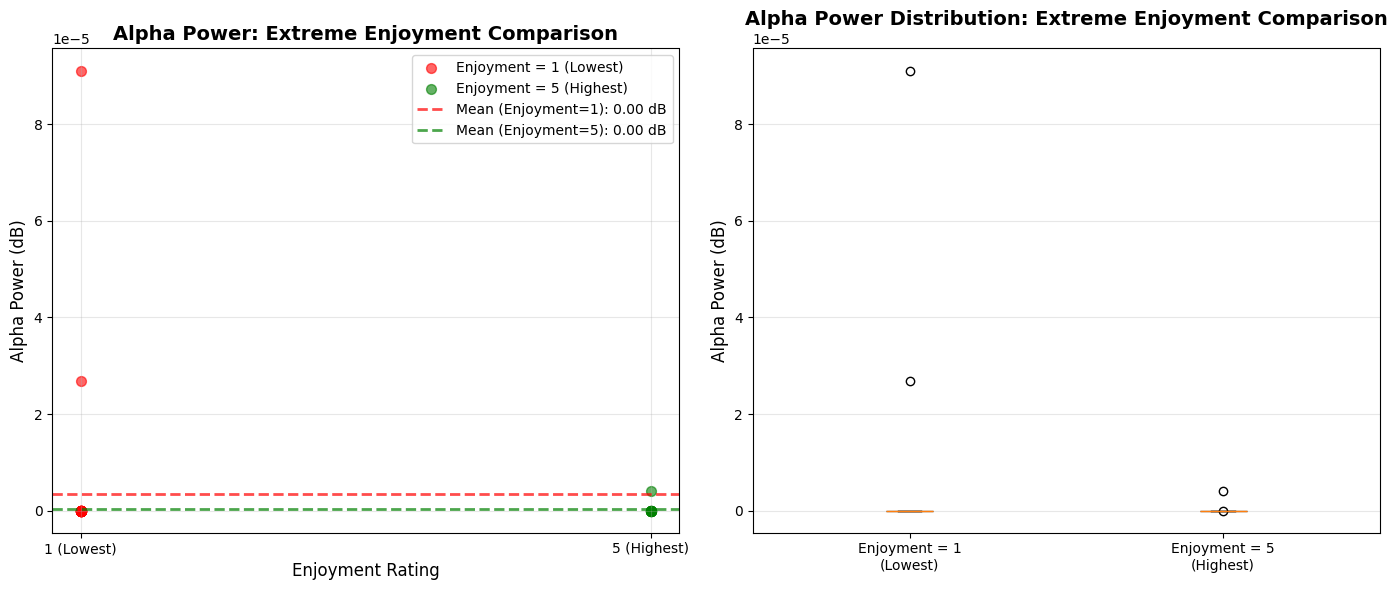


STATISTICAL COMPARISON: Enjoyment 1 vs 5

Enjoyment = 1 (Lowest):
  Mean Alpha Power: 0.000 dB
  Std: 0.000 dB
  N: 34

Enjoyment = 5 (Highest):
  Mean Alpha Power: 0.000 dB
  Std: 0.000 dB
  N: 11

Difference:
  Mean difference: -0.000 dB
  (Enjoyment 5 - Enjoyment 1)

T-test results:
  t-statistic: -0.633
  p-value: 0.5303
  → No significant difference (p >= 0.05)


In [ ]:
# Graph 3: Alpha Power vs Extreme Enjoyment Scores (1 vs 5)
if 'alpha_enjoyment_df' in locals() and len(alpha_enjoyment_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    enjoyment_1 = alpha_enjoyment_df[alpha_enjoyment_df['Enjoyment'] == 1]['Alpha_Power']
    enjoyment_5 = alpha_enjoyment_df[alpha_enjoyment_df['Enjoyment'] == 5]['Alpha_Power']
    
    axes[0].scatter([1]*len(enjoyment_1), enjoyment_1, 
                   alpha=0.6, s=50, color='red', label='Enjoyment = 1 (Lowest)')
    axes[0].scatter([5]*len(enjoyment_5), enjoyment_5, 
                   alpha=0.6, s=50, color='green', label='Enjoyment = 5 (Highest)')
    
    if len(enjoyment_1) > 0:
        axes[0].axhline(y=enjoyment_1.mean(), color='red', linestyle='--', 
                       alpha=0.7, linewidth=2, label=f'Mean (Enjoyment=1): {enjoyment_1.mean():.2f} dB')
    if len(enjoyment_5) > 0:
        axes[0].axhline(y=enjoyment_5.mean(), color='green', linestyle='--', 
                       alpha=0.7, linewidth=2, label=f'Mean (Enjoyment=5): {enjoyment_5.mean():.2f} dB')
    
    axes[0].set_xlabel('Enjoyment Rating', fontsize=12)
    axes[0].set_ylabel('Alpha Power (dB)', fontsize=12)
    axes[0].set_title('Alpha Power: Extreme Enjoyment Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xticks([1, 5])
    axes[0].set_xticklabels(['1 (Lowest)', '5 (Highest)'])
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(alpha=0.3)
    
    # Box plot
    if len(enjoyment_1) > 0 and len(enjoyment_5) > 0:
        bp = axes[1].boxplot([enjoyment_1, enjoyment_5], 
                            labels=['Enjoyment = 1\n(Lowest)', 'Enjoyment = 5\n(Highest)'], 
                            patch_artist=True)
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor('lightgreen')
        bp['boxes'][1].set_alpha(0.7)
        
        axes[1].set_ylabel('Alpha Power (dB)', fontsize=12)
        axes[1].set_title('Alpha Power Distribution: Extreme Enjoyment Comparison', fontsize=14, fontweight='bold')
        axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical comparison
    if len(enjoyment_1) > 0 and len(enjoyment_5) > 0:
        from scipy import stats
        
        mean_1 = enjoyment_1.mean()
        mean_5 = enjoyment_5.mean()
        std_1 = enjoyment_1.std()
        std_5 = enjoyment_5.std()
        
        print(f"\n{'='*60}")
        print("STATISTICAL COMPARISON: Enjoyment 1 vs 5")
        print(f"{'='*60}")
        print(f"\nEnjoyment = 1 (Lowest):")
        print(f"  Mean Alpha Power: {mean_1:.3f} dB")
        print(f"  Std: {std_1:.3f} dB")
        print(f"  N: {len(enjoyment_1)}")
        
        print(f"\nEnjoyment = 5 (Highest):")
        print(f"  Mean Alpha Power: {mean_5:.3f} dB")
        print(f"  Std: {std_5:.3f} dB")
        print(f"  N: {len(enjoyment_5)}")
        
        print(f"\nDifference:")
        print(f"  Mean difference: {mean_5 - mean_1:.3f} dB")
        print(f"  (Enjoyment 5 - Enjoyment 1)")
        
        # Perform t-test
        t_stat, p_value = stats.ttest_ind(enjoyment_5, enjoyment_1)
        print(f"\nT-test results:")
        print(f"  t-statistic: {t_stat:.3f}")
        print(f"  p-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"  ✓ Significant difference (p < 0.05)")
            if mean_5 > mean_1:
                print(f"  → Higher alpha power for Enjoyment = 5 (highest enjoyment)")
            else:
                print(f"  → Higher alpha power for Enjoyment = 1 (lowest enjoyment)")
        else:
            print(f"  → No significant difference (p >= 0.05)")
        print(f"{'='*60}")

# Brain Topography Analysis

## Goal
Map brain activity across the scalp using 128 EEG channels.

## Research Questions
1. Which brain regions activate during music listening?
2. Does frontal cortex respond to enjoyable music?

In [58]:
# Function to compute average band power for each channel
def compute_channel_band_power(tfr, band_name, tmin=None, tmax=None, to_db=True):
    """
    Compute average band power for each channel.
    
    Parameters:
    -----------
    tfr : mne.time_frequency.TFR
        Time-frequency representation
    band_name : str
        Frequency band name ('delta', 'theta', 'alpha', 'beta', 'gamma')
    tmin : float or None
        Start time for averaging (seconds). If None, uses all times.
    tmax : float or None
        End time for averaging (seconds). If None, uses all times.
        
    Returns:
    --------
    channel_power : array
        Average power for each channel (n_channels,). By default returned in dB (log10 scale).
    """
    if band_name not in FREQ_BANDS:
        raise ValueError(f"Unknown band: {band_name}. Choose from {list(FREQ_BANDS.keys())}")
    
    fmin, fmax = FREQ_BANDS[band_name]
    
    # Find frequency indices
    freq_mask = (tfr.freqs >= fmin) & (tfr.freqs <= fmax)
    
    # Extract data: channels x freqs x times
    data = tfr.data[:, freq_mask, :]
    
    # Average across frequencies
    band_power = np.mean(data, axis=1)  # channels x times
    
    # Average across time if time window specified
    if tmin is not None or tmax is not None:
        if tmin is None:
            tmin = tfr.times[0]
        if tmax is None:
            tmax = tfr.times[-1]
        time_mask = (tfr.times >= tmin) & (tfr.times <= tmax)
        channel_power = np.mean(band_power[:, time_mask], axis=1)
    else:
        # Average across all times
        channel_power = np.mean(band_power, axis=1)
    
    # Convert to dB if requested (makes values interpretable; linear power can be extremely small)
    if to_db:
        eps = np.finfo(float).eps
        channel_power = 10 * np.log10(channel_power + eps)

    return channel_power

print("Function compute_channel_band_power defined!")

Function compute_channel_band_power defined!


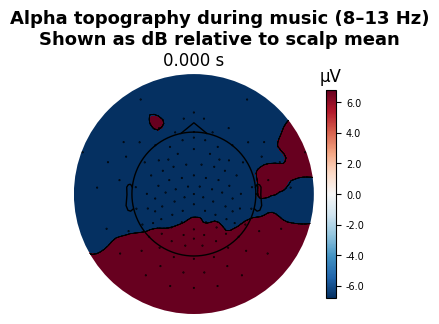

✓ Alpha power topomap plotted
  Channels: 129
  Alpha power range (linear): 1.248e-10 - 1.838e-09
  Alpha power range (absolute dB): -99.04 - -87.36 dB
  Alpha power range (relative dB): -4.88 - 6.80 dB (centered at 0)


In [ ]:
# Graph 5: Topomap for Alpha Power During Music Listening
# Create a topomap showing alpha power distribution across the scalp
try:
    from mne import EvokedArray
except ImportError:
    from mne.evoked import EvokedArray

if 'test_power' in locals() and test_power is not None:
    alpha_channel_power = compute_channel_band_power(test_power, 'alpha', tmin=0, tmax=None)
    alpha_freq_mask = (test_power.freqs >= 8) & (test_power.freqs <= 13)
    time_mask = test_power.times > 0  # Music listening period
    
    alpha_data = np.mean(test_power.data[:, alpha_freq_mask, :][:, :, time_mask], axis=(1, 2))
    eps = np.finfo(float).eps
    alpha_data_db = 10 * np.log10(alpha_data + eps)
    alpha_rel_db = alpha_data_db - np.mean(alpha_data_db)
    info = test_power.info.copy()
    evoked_data = alpha_rel_db[:, np.newaxis]
    evoked = EvokedArray(evoked_data, info, tmin=0)
    vmax = float(np.max(np.abs(alpha_rel_db)))
    vlim = (-vmax, vmax)

    # Plot topomap
    fig = evoked.plot_topomap(
        times=[0],
        ch_type='eeg',
        show=False,
        colorbar=True,
        cmap='RdBu_r',
        vlim=vlim,
        size=2.0,
    )

    # Title
    title = 'Alpha topography during music (8–13 Hz)\nShown as dB relative to scalp mean'
    if isinstance(fig, list):
        fig[0].suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    else:
        fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)

    plt.show()

    print("✓ Alpha power topomap plotted")
    print(f"  Channels: {len(test_power.ch_names)}")
    print(f"  Alpha power range (linear): {alpha_data.min():.3e} - {alpha_data.max():.3e}")
    print(f"  Alpha power range (absolute dB): {alpha_data_db.min():.2f} - {alpha_data_db.max():.2f} dB")
    print(f"  Alpha power range (relative dB): {alpha_rel_db.min():.2f} - {alpha_rel_db.max():.2f} dB (centered at 0)")
else:
    print("No test_power available. Run TFR computation first.")

In [ ]:
# Research Question: Does frontal cortex respond to enjoyable music?
# Compare alpha power in frontal regions for Enjoyment = 1 vs Enjoyment = 5

def analyze_frontal_alpha_enjoyment():
    """
    Analyze alpha power in frontal cortex for extreme enjoyment scores.
    
    Returns:
    --------
    frontal_results : DataFrame
        DataFrame with frontal alpha power for Enjoyment 1 and 5
    """
    results = []
    
    # Filter for only extreme enjoyment scores (1 and 5)
    extreme_enjoyment = df[df['Enjoyment'].isin([1, 5])].copy()
    
    print(f"Analyzing frontal alpha power for extreme enjoyment scores...")
    print(f"Found {len(extreme_enjoyment)} subject-song combinations")
    print("This may take several minutes...")
    
    # For EGI 128, frontal channels are roughly channels 1-30 (anterior region)
    frontal_channel_patterns = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10',
                                'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20',
                                'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30']
    
    for idx, row in extreme_enjoyment.iterrows():
        subject_id = row['Subject']
        song_id = row['Song_ID']
        enjoyment_val = row['Enjoyment']
        
        # Load and process EEG
        raw, events, event_id = load_eeg_data(subject_id, song_id, base_path)
        if raw is None:
            continue
        
        try:
            raw_proc = preprocess_eeg(raw, apply_filter=True)
            epochs = create_music_epochs(raw_proc, events, event_id, 
                                       tmin=-1.0, tmax=min(120.0, raw_proc.times[-1]))
            if len(epochs) == 0:
                continue
            freqs = np.arange(1, 51, 2)
            power = compute_tfr(epochs, freqs=freqs, n_cycles=5)
            alpha_channel_power = compute_channel_band_power(power, 'alpha', tmin=0, tmax=None)
            
            frontal_indices = []
            for i, ch_name in enumerate(power.ch_names):
                if any(pattern in ch_name for pattern in frontal_channel_patterns) or i < 30:
                    frontal_indices.append(i)
            
            if len(frontal_indices) > 0:
                frontal_alpha = np.mean(alpha_channel_power[frontal_indices])
                overall_alpha = np.mean(alpha_channel_power)
                results.append({
                    'Subject': subject_id,
                    'Song_ID': song_id,
                    'Enjoyment': enjoyment_val,
                    'Frontal_Alpha_Power': frontal_alpha,
                    'Overall_Alpha_Power': overall_alpha,
                    'N_Frontal_Channels': len(frontal_indices)
                })
            
            # Clean up memory
            del raw, raw_proc, epochs, power, alpha_channel_power
            
        except Exception as e:
            print(f"  Error processing Subject {subject_id}, Song {song_id}: {e}")
            continue
    
    results_df = pd.DataFrame(results)
    return results_df

print("="*60)
print("FRONTAL CORTEX ANALYSIS: Alpha Power vs Enjoyment")
print("="*60)
frontal_alpha_df = analyze_frontal_alpha_enjoyment()

if len(frontal_alpha_df) > 0:
    print(f"\n✓ Analysis complete: {len(frontal_alpha_df)} subject-song combinations")
    print(frontal_alpha_df.head(10))
else:
    print("No data processed.")

FRONTAL CORTEX ANALYSIS: Alpha Power vs Enjoyment
Analyzing frontal alpha power for extreme enjoyment scores...
Found 50 subject-song combinations
This may take several minutes...
  Using stim event at 7.41s (sample 1852)
  Recording duration: 136.50s, available time after event: 129.09s
  Using 1 valid event(s) out of 1 total
  Using stim event at 7.41s (sample 1852)
  Recording duration: 123.15s, available time after event: 115.74s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.25s (sample 7245)
  Recording duration: 123.15s, available time after event: 115.90s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.44s (sample 7437)
  Recording duration: 124.92s, available time after event: 117.48s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.44s (sample 7437)
  Recording duration: 142.78s, available time after event: 135.35s
  Using 1 valid event(s) out of 1 total
  Using s

In [71]:
frontal_alpha_df.to_csv('frontal_alpha_df.csv')

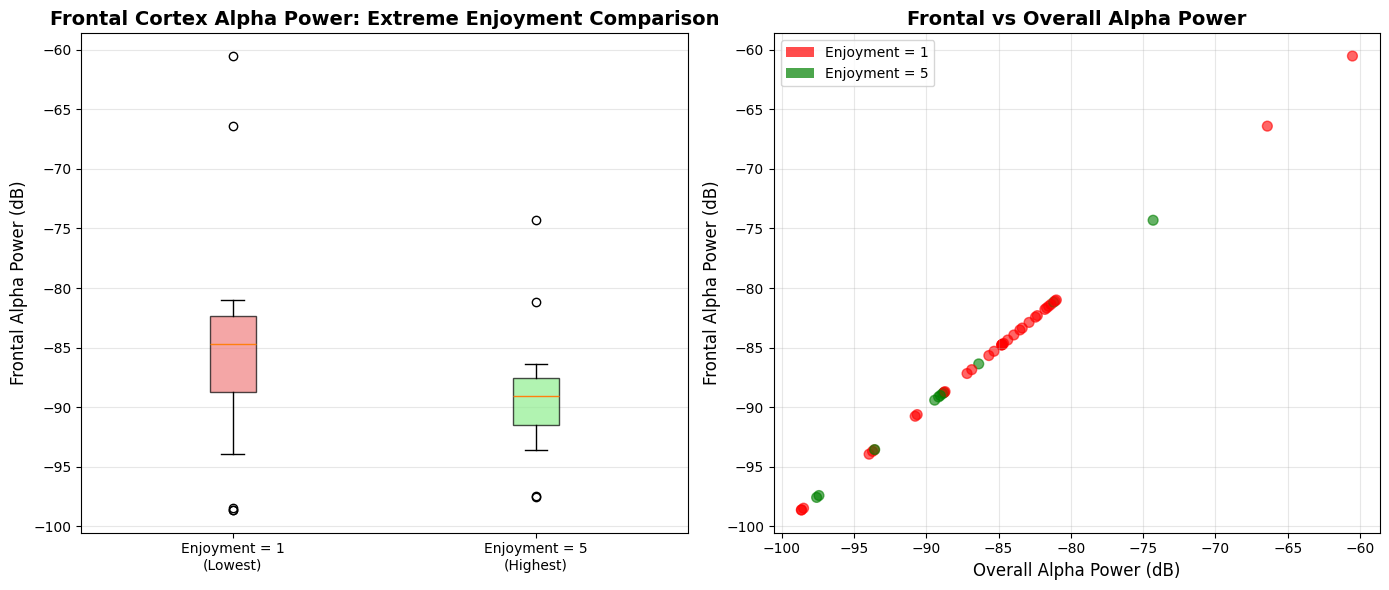


FRONTAL CORTEX STATISTICAL COMPARISON

Enjoyment = 1 (Lowest):
  Mean Frontal Alpha: -85.375 dB
  Std: 7.640 dB
  N: 34

Enjoyment = 5 (Highest):
  Mean Frontal Alpha: -88.694 dB
  Std: 6.694 dB
  N: 11

Difference:
  Mean difference: -3.319 dB

T-test results:
  t-statistic: -1.288
  p-value: 0.2047
  → No significant difference (p >= 0.05)


In [61]:
# Graph 6: Frontal Alpha Power Comparison (Enjoyment 1 vs 5)
if 'frontal_alpha_df' in locals() and len(frontal_alpha_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Separate data by enjoyment level
    frontal_enjoyment_1 = frontal_alpha_df[frontal_alpha_df['Enjoyment'] == 1]['Frontal_Alpha_Power']
    frontal_enjoyment_5 = frontal_alpha_df[frontal_alpha_df['Enjoyment'] == 5]['Frontal_Alpha_Power']
    
    # Box plot comparison
    bp = axes[0].boxplot([frontal_enjoyment_1, frontal_enjoyment_5], 
                        labels=['Enjoyment = 1\n(Lowest)', 'Enjoyment = 5\n(Highest)'], 
                        patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('lightgreen')
    bp['boxes'][1].set_alpha(0.7)
    
    axes[0].set_ylabel('Frontal Alpha Power (dB)', fontsize=12)
    axes[0].set_title('Frontal Cortex Alpha Power: Extreme Enjoyment Comparison', 
                      fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='y')
    
    # Scatter plot: Frontal vs Overall alpha power
    colors = ['red' if e == 1 else 'green' for e in frontal_alpha_df['Enjoyment']]
    axes[1].scatter(frontal_alpha_df['Overall_Alpha_Power'], 
                   frontal_alpha_df['Frontal_Alpha_Power'],
                   c=colors, alpha=0.6, s=50)
    axes[1].set_xlabel('Overall Alpha Power (dB)', fontsize=12)
    axes[1].set_ylabel('Frontal Alpha Power (dB)', fontsize=12)
    axes[1].set_title('Frontal vs Overall Alpha Power', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='red', alpha=0.7, label='Enjoyment = 1'),
                      Patch(facecolor='green', alpha=0.7, label='Enjoyment = 5')]
    axes[1].legend(handles=legend_elements, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical comparison
    if len(frontal_enjoyment_1) > 0 and len(frontal_enjoyment_5) > 0:
        from scipy import stats
        
        mean_1 = frontal_enjoyment_1.mean()
        mean_5 = frontal_enjoyment_5.mean()
        
        print(f"\n{'='*60}")
        print("FRONTAL CORTEX STATISTICAL COMPARISON")
        print(f"{'='*60}")
        print(f"\nEnjoyment = 1 (Lowest):")
        print(f"  Mean Frontal Alpha: {mean_1:.3f} dB")
        print(f"  Std: {frontal_enjoyment_1.std():.3f} dB")
        print(f"  N: {len(frontal_enjoyment_1)}")
        
        print(f"\nEnjoyment = 5 (Highest):")
        print(f"  Mean Frontal Alpha: {mean_5:.3f} dB")
        print(f"  Std: {frontal_enjoyment_5.std():.3f} dB")
        print(f"  N: {len(frontal_enjoyment_5)}")
        
        print(f"\nDifference:")
        print(f"  Mean difference: {mean_5 - mean_1:.3f} dB")
        
        # T-test
        t_stat, p_value = stats.ttest_ind(frontal_enjoyment_5, frontal_enjoyment_1)
        print(f"\nT-test results:")
        print(f"  t-statistic: {t_stat:.3f}")
        print(f"  p-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"  ✓ Significant difference (p < 0.05)")
            if mean_5 > mean_1:
                print(f"  → Higher frontal alpha for Enjoyment = 5")
                print(f"  → Frontal cortex shows increased activity for enjoyable music")
            else:
                print(f"  → Higher frontal alpha for Enjoyment = 1")
        else:
            print(f"  → No significant difference (p >= 0.05)")
        print(f"{'='*60}")

Creating topomaps for extreme enjoyment examples...
Enjoyment = 1 examples: 3
Enjoyment = 5 examples: 3
  Using stim event at 7.41s (sample 1852)
  Recording duration: 136.50s, available time after event: 129.09s
  Using 1 valid event(s) out of 1 total
  Using stim event at 7.41s (sample 1852)
  Recording duration: 123.15s, available time after event: 115.74s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.25s (sample 7245)
  Recording duration: 123.15s, available time after event: 115.90s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.44s (sample 7437)
  Recording duration: 121.47s, available time after event: 114.03s
  Events outside valid range, creating fixed-length epochs...
  Using stim event at 7.41s (sample 7411)
  Recording duration: 136.50s, available time after event: 129.09s
  Using 1 valid event(s) out of 1 total
  Using stim event at 7.52s (sample 1880)
  Recording duration: 142.80s, available ti

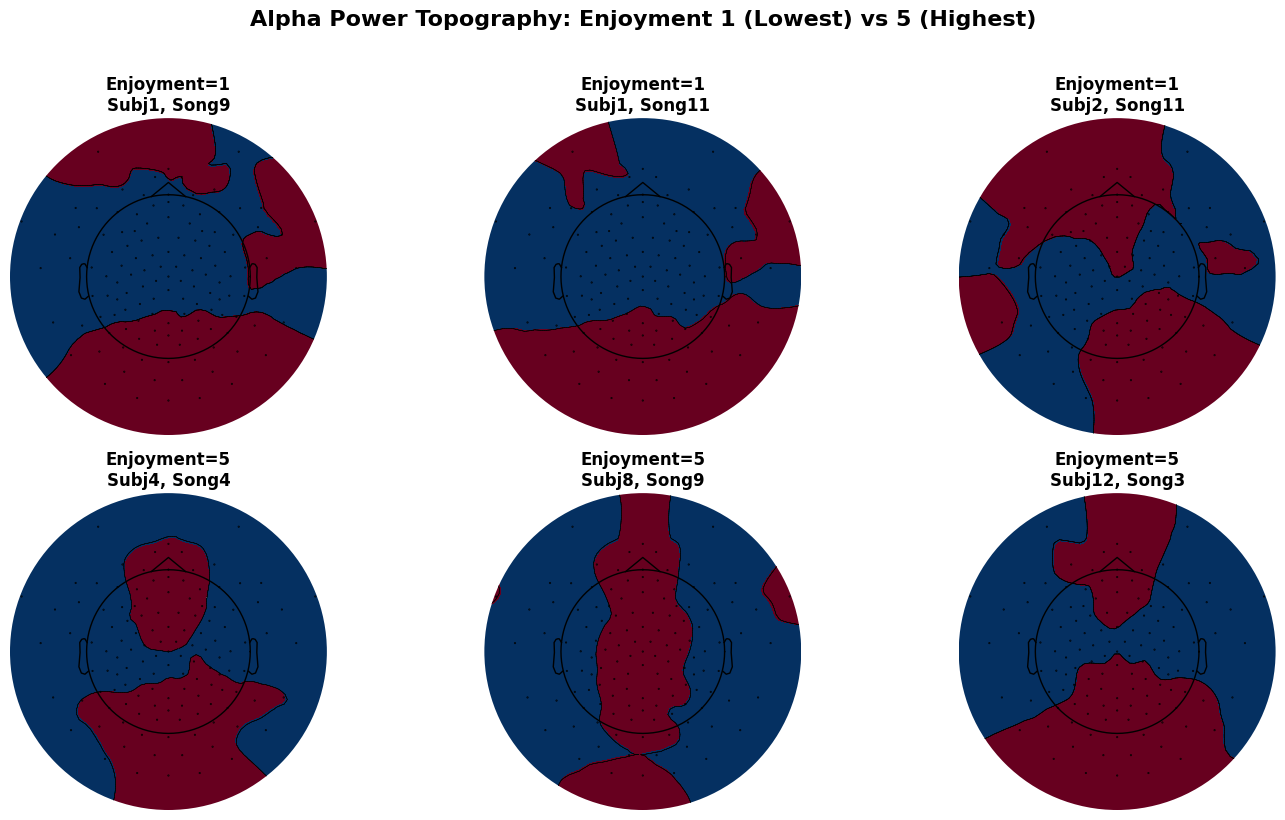

✓ Topomaps plotted


In [63]:
# Graph 7: Topomaps Comparing Enjoyment 1 vs 5
# Create topomaps showing alpha power distribution for extreme enjoyment scores

# Import EvokedArray if not already imported
try:
    from mne import EvokedArray
except ImportError:
    from mne.evoked import EvokedArray

if 'frontal_alpha_df' in locals() and len(frontal_alpha_df) > 0:
    # Get examples from each group
    enjoyment_1_examples = frontal_alpha_df[frontal_alpha_df['Enjoyment'] == 1].head(3)
    enjoyment_5_examples = frontal_alpha_df[frontal_alpha_df['Enjoyment'] == 5].head(3)
    
    print("Creating topomaps for extreme enjoyment examples...")
    print(f"Enjoyment = 1 examples: {len(enjoyment_1_examples)}")
    print(f"Enjoyment = 5 examples: {len(enjoyment_5_examples)}")
    
    fig, axes = plt.subplots(2, max(len(enjoyment_1_examples), len(enjoyment_5_examples)), 
                             figsize=(15, 8))
    
    if len(enjoyment_1_examples) == 0 or len(enjoyment_5_examples) == 0:
        print("Not enough examples for comparison. Need at least one of each enjoyment level.")
    else:
        # Plot Enjoyment = 1 topomaps
        for idx, (_, row) in enumerate(enjoyment_1_examples.iterrows()):
            subject_id = int(row['Subject'])
            song_id = int(row['Song_ID'])
            
            try:
                # Load and process
                raw, events, event_id = load_eeg_data(subject_id, song_id, base_path)
                if raw is None:
                    continue
                
                raw_proc = preprocess_eeg(raw, apply_filter=True)
                epochs = create_music_epochs(raw_proc, events, event_id, 
                                           tmin=-1.0, tmax=min(120.0, raw_proc.times[-1]))
                
                if len(epochs) == 0:
                    continue
                
                # Compute TFR and alpha power
                freqs = np.arange(1, 51, 2)
                power = compute_tfr(epochs, freqs=freqs, n_cycles=5)
                alpha_channel_power = compute_channel_band_power(power, 'alpha', tmin=0, tmax=None)
                
                # Create evoked object for topomap
                info = power.info.copy()

                # Use relative topography (centered at 0) for better contrast
                alpha_rel_db = alpha_channel_power - np.mean(alpha_channel_power)
                vmax = float(np.max(np.abs(alpha_rel_db)))
                vlim = (-vmax, vmax)

                evoked_data = alpha_rel_db[:, np.newaxis]
                evoked = EvokedArray(evoked_data, info, tmin=0)
                
                # Plot topomap
                # Handle axes properly for subplot
                if len(enjoyment_1_examples) == 1 and len(enjoyment_5_examples) == 1:
                    ax = axes[0]
                elif len(enjoyment_1_examples) == 1:
                    ax = axes[0, idx] if isinstance(axes, np.ndarray) else axes[0]
                else:
                    ax = axes[0, idx] if isinstance(axes, np.ndarray) else axes[idx]
                
                evoked.plot_topomap(
                    times=[0],
                    ch_type='eeg',
                    show=False,
                    axes=ax,
                    colorbar=False,
                    cmap='RdBu_r',
                    vlim=vlim,
                )
                ax.set_title(f'Enjoyment=1\nSubj{subject_id}, Song{song_id}', 
                           fontsize=12, fontweight='bold')
                
                del raw, raw_proc, epochs, power
                
            except Exception as e:
                print(f"  Error creating topomap for Subject {subject_id}, Song {song_id}: {e}")
        
        # Plot Enjoyment = 5 topomaps
        for idx, (_, row) in enumerate(enjoyment_5_examples.iterrows()):
            subject_id = int(row['Subject'])
            song_id = int(row['Song_ID'])
            
            try:
                # Load and process
                raw, events, event_id = load_eeg_data(subject_id, song_id, base_path)
                if raw is None:
                    continue
                
                raw_proc = preprocess_eeg(raw, apply_filter=True)
                epochs = create_music_epochs(raw_proc, events, event_id, 
                                           tmin=-1.0, tmax=min(120.0, raw_proc.times[-1]))
                
                if len(epochs) == 0:
                    continue
                
                # Compute TFR and alpha power
                freqs = np.arange(1, 51, 2)
                power = compute_tfr(epochs, freqs=freqs, n_cycles=5)
                alpha_channel_power = compute_channel_band_power(power, 'alpha', tmin=0, tmax=None)
                
                # Create evoked object for topomap
                info = power.info.copy()

                # Use relative topography (centered at 0) for better contrast
                alpha_rel_db = alpha_channel_power - np.mean(alpha_channel_power)
                vmax = float(np.max(np.abs(alpha_rel_db)))
                vlim = (-vmax, vmax)

                evoked_data = alpha_rel_db[:, np.newaxis]
                evoked = EvokedArray(evoked_data, info, tmin=0)
                
                # Plot topomap
                # Handle axes properly for subplot
                if len(enjoyment_5_examples) == 1 and len(enjoyment_1_examples) == 1:
                    ax = axes[1]
                elif len(enjoyment_5_examples) == 1:
                    ax = axes[1, idx] if isinstance(axes, np.ndarray) else axes[1]
                else:
                    ax = axes[1, idx] if isinstance(axes, np.ndarray) else axes[idx]
                
                # No colorbar inside subplots (avoids layout issues). Use symmetric vlim/cmap.
                evoked.plot_topomap(
                    times=[0],
                    ch_type='eeg',
                    show=False,
                    axes=ax,
                    colorbar=False,
                    cmap='RdBu_r',
                    vlim=vlim,
                )
                ax.set_title(f'Enjoyment=5\nSubj{subject_id}, Song{song_id}', 
                           fontsize=12, fontweight='bold')
                
                del raw, raw_proc, epochs, power
                
            except Exception as e:
                print(f"  Error creating topomap for Subject {subject_id}, Song {song_id}: {e}")
        
        plt.suptitle('Alpha Power Topography: Enjoyment 1 (Lowest) vs 5 (Highest)', 
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
        print("✓ Topomaps plotted")
else:
    print("No frontal alpha data available. Run frontal analysis first.")

In [64]:
# Summary: Brain Topography Analysis
print("="*60)
print("BRAIN TOPOGRAPHY ANALYSIS SUMMARY")
print("="*60)

print("\nAnalysis Completed:")
print("  ✓ Alpha power computed for each of 128 channels")
print("  ✓ Topomaps created showing spatial distribution")
print("  ✓ Frontal cortex analysis for extreme enjoyment scores")

if 'frontal_alpha_df' in locals() and len(frontal_alpha_df) > 0:
    frontal_enjoyment_1 = frontal_alpha_df[frontal_alpha_df['Enjoyment'] == 1]['Frontal_Alpha_Power']
    frontal_enjoyment_5 = frontal_alpha_df[frontal_alpha_df['Enjoyment'] == 5]['Frontal_Alpha_Power']
    
    if len(frontal_enjoyment_1) > 0 and len(frontal_enjoyment_5) > 0:
        from scipy import stats
        t_stat, p_value = stats.ttest_ind(frontal_enjoyment_5, frontal_enjoyment_1)
        
        print(f"\nResearch Question: Does frontal cortex respond to enjoyable music?")
        print(f"  Frontal alpha power comparison:")
        print(f"    Enjoyment = 1: {frontal_enjoyment_1.mean():.3f} ± {frontal_enjoyment_1.std():.3f} dB")
        print(f"    Enjoyment = 5: {frontal_enjoyment_5.mean():.3f} ± {frontal_enjoyment_5.std():.3f} dB")
        print(f"    Difference: {frontal_enjoyment_5.mean() - frontal_enjoyment_1.mean():.3f} dB")
        print(f"    p-value: {p_value:.4f}")
        
        if p_value < 0.05:
            if frontal_enjoyment_5.mean() > frontal_enjoyment_1.mean():
                print(f"  → YES: Frontal cortex shows increased alpha activity for enjoyable music")
            else:
                print(f"  → YES: Frontal cortex shows different activity patterns")
        else:
            print(f"  → No significant difference found in frontal cortex")

print("\n" + "="*60)

BRAIN TOPOGRAPHY ANALYSIS SUMMARY

Analysis Completed:
  ✓ Alpha power computed for each of 128 channels
  ✓ Topomaps created showing spatial distribution
  ✓ Frontal cortex analysis for extreme enjoyment scores

Research Question: Does frontal cortex respond to enjoyable music?
  Frontal alpha power comparison:
    Enjoyment = 1: -85.375 ± 7.640 dB
    Enjoyment = 5: -88.694 ± 6.694 dB
    Difference: -3.319 dB
    p-value: 0.2047
  → No significant difference found in frontal cortex



In [75]:
df.groupby('Familiarity').count()

,Subject,Song_ID,Enjoyment
Familiarity,,,
1,14,14,14
2,37,37,37
3,46,46,46
4,80,80,80
5,63,63,63
